In [481]:

from pymongo import MongoClient
import pandas as pd

try: 
    client = MongoClient("localhost", 5001)
    print("Connected successfully!!!") 
except:
    print("Could not connect to MongoDB")

db = client["flask_db"]
activity = db.activity



Connected successfully!!!


In [482]:
project_ids = (
    "656fadd102ae94a7686aae62",
    "640e22cae918523bcee8ca5e",
    "6543b8ee4180527babd20c3a",
    "656a440644dec9f71f2dee44",
    "654682f220e7d557c7e67cff",
    "6470fc81c8542274b9582aa1"
)

project_id = project_ids[5]
#project_id = "6516fce1459696e2363e98ef"

query = {"project": project_id, "editingLines": {"$exists": True, "$ne": None}}

cursor = activity.find(query)

df = pd.DataFrame(list(cursor))
#df = df.astype({"text": str, "state": str, "line": str, "username": str, "project": str, "file": str, "message": str})

col_names = df.columns.tolist()
dtypes = df.dtypes
df.head()

,_id,timestamp,text,revision,state,line,username,project,file,editingLines,message,changes,selected_text,target,suggestion,explanation,accept,start,clipboard,assistError
0,65497552f0485be5bf50b2a4,1699312978052,\section{Introduction}\n\nLarge Language Model...,"[[0, \section{Introduction}\n\nLarge Language ...",Typing,4,Ritik Sachin,6470fc81c8542274b9582aa1,1_introduction.tex,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",Typing,"[(4,0), Hi ---added]",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,65497554f0485be5bf50b2a5,1699312980059,\section{Introduction}\n\nLarge Language Model...,"[[0, \section{Introduction}\n\nLarge Language ...",Typing,5,Ritik Sachin,6470fc81c8542274b9582aa1,1_introduction.tex,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",Typing,"[(5,0), \n---added]",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,6549755ef0485be5bf50b2a6,1699312990246,\section{Introduction}\n\nLarge Language Model...,"[[0, \section{Introduction}\n\nLarge Language ...",Typing,4,Ritik Sachin,6470fc81c8542274b9582aa1,1_introduction.tex,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",Typing,"[(4,0), \n---deleted]",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,6549755ff0485be5bf50b2a7,1699312991344,\section{Introduction}\n\nLarge Language Model...,"[[0, \section{Introduction}\n\nLarge Language ...",Typing,4,Ritik Sachin,6470fc81c8542274b9582aa1,1_introduction.tex,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",Typing,"[(4,2), ---deleted]",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,65497560f0485be5bf50b2a8,1699312991693,\section{Introduction}\n\nLarge Language Model...,"[[0, \section{Introduction}\n\nLarge Language ...",Typing,4,Ritik Sachin,6470fc81c8542274b9582aa1,1_introduction.tex,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",Typing,"[(4,2), ---added]",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [483]:
print("column names", col_names)
print("num rows", len(df))

print("average len", df["editingLines"].apply(len).mean())
print("median len", df["editingLines"].apply(len).median())
print("mode len", df["editingLines"].apply(len).mode().tolist())

column names ['_id', 'timestamp', 'text', 'revision', 'state', 'line', 'username', 'project', 'file', 'editingLines', 'message', 'changes', 'selected_text', 'target', 'suggestion', 'explanation', 'accept', 'start', 'clipboard', 'assistError']
num rows 7467
average len 34.74675237712602
median len 33.0
mode len [21]


In [484]:
print("unique files in project", df["file"].unique())

unique files in project ['1_introduction.tex' 'custom.bib' '4_experiments.tex' 'main.tex'
 'main_alpaca.tex' 'main_dolly.tex' '2_related_works.tex'
 'main_ablation.tex' '5_experiments.tex' 'main_examples.tex'
 '7_appendix.tex' 'main_gpt_eval.tex' 'Figure4_examples.tex'
 'Figure1_main.tex' 'main_instructions.tex' 'main_cross_eval.tex'
 '4_method.tex' 'prompt_complex.tex' '6_conclusion_and_future_work.tex'
 'main_cot.tex' 'Figure_prompt.tex']


In [485]:
df1 = df["username"].value_counts().sort_values()
df["line_counts"] = df["editingLines"].apply(len)

df2 = df.groupby(["username"])["line_counts"].sum().sort_values()
print(df.head())

print(df1)
print(df2)


                        _id      timestamp  \
0  65497552f0485be5bf50b2a4  1699312978052   
1  65497554f0485be5bf50b2a5  1699312980059   
2  6549755ef0485be5bf50b2a6  1699312990246   
3  6549755ff0485be5bf50b2a7  1699312991344   
4  65497560f0485be5bf50b2a8  1699312991693   

                                                text  \
0  \section{Introduction}\n\nLarge Language Model...   
1  \section{Introduction}\n\nLarge Language Model...   
2  \section{Introduction}\n\nLarge Language Model...   
3  \section{Introduction}\n\nLarge Language Model...   
4  \section{Introduction}\n\nLarge Language Model...   

                                            revision   state line  \
0  [[0, \section{Introduction}\n\nLarge Language ...  Typing    4   
1  [[0, \section{Introduction}\n\nLarge Language ...  Typing    5   
2  [[0, \section{Introduction}\n\nLarge Language ...  Typing    4   
3  [[0, \section{Introduction}\n\nLarge Language ...  Typing    4   
4  [[0, \section{Introduction}\n\nLarge L

['Ritik Sachin' 'Jong Inn' 'parka438']


/home/ross/miniconda3/envs/ml39/lib/python3.9/site-packages/seaborn/categorical.py:486: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

/home/ross/miniconda3/envs/ml39/lib/python3.9/site-packages/seaborn/categorical.py:486: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`



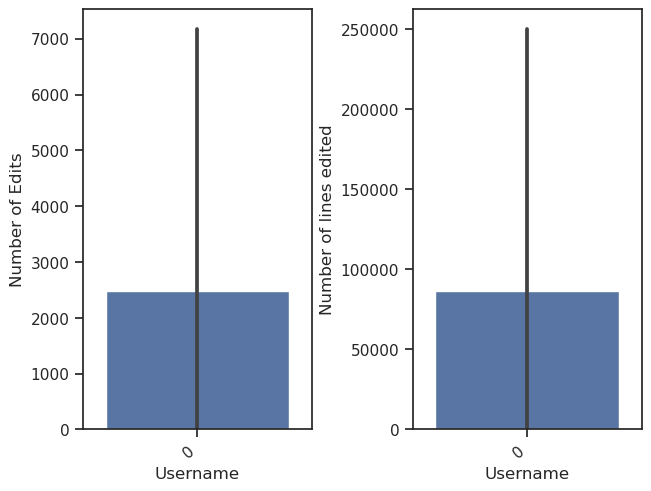

In [486]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import colorcet as cc

sns.set_theme(style="ticks")

print(df["username"].unique())

fig, (ax1, ax2) = plt.subplots(1, 2, constrained_layout = True) 

ax1 = sns.barplot(df1, ax=ax1)
ax1.set(xlabel='Username', ylabel='Number of Edits')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=40, ha="right")


ax2 = sns.barplot(df2, ax=ax2)
ax2.set(xlabel="Username", ylabel="Number of lines edited")
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=40, ha="right")

fig.savefig(f"figures/{project_id}_edits_fig.png")




In [487]:
def count_op(op, revision):
    count = 0
    
    for l in revision:
        curr_op = l[0]

        if (op is None):
            count += len(l[1])
        if curr_op == op:
            count += op * len(l[1])

    return count
        

/home/ross/miniconda3/envs/ml39/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.

/home/ross/miniconda3/envs/ml39/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.

/tmp/ipykernel_1663737/45329987.py:11: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



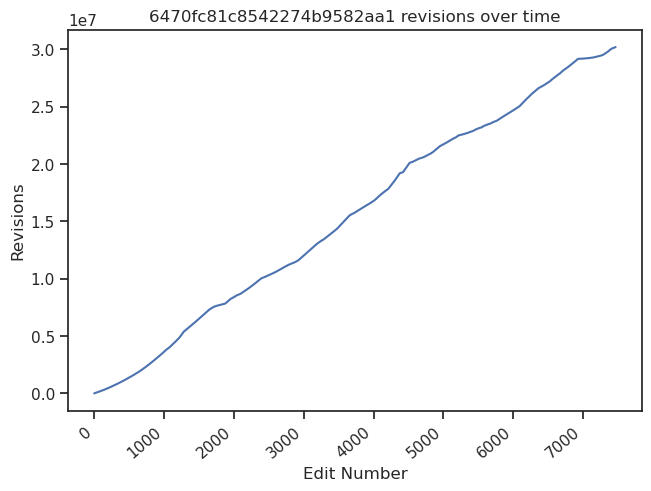

In [488]:
#df["edits"] = df["revision"].apply(len)
df["edits"] = df.apply(lambda x: count_op(None, x["revision"]), axis=1)

df["cum_edits"] = df["edits"].cumsum()

fig, ax = plt.subplots(1, 1, constrained_layout = True) 

ax = sns.lineplot(df["cum_edits"], ax=ax)
ax.set(xlabel='Edit Number', ylabel='Revisions')
ax.set_title(f"{project_id} revisions over time")
ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha="right")

fig.savefig(f"figures/{project_id}_revisions_fig.png")


# File edits across time

Currenly only showing .tex or .bib files

Index([1699312978052, 1699312980059, 1699312990246, 1699312991344,
       1699312991693, 1699312991992, 1699312992342, 1699312992672,
       1699312999307, 1699313043191,
       ...
       1706233490600, 1706233752767, 1706233922808, 1706234008877,
       1706234064660, 1706234068363, 1706234070604, 1706234437129,
       1707767081128, 1707767081286],
      dtype='int64', name='timestamp', length=7361)


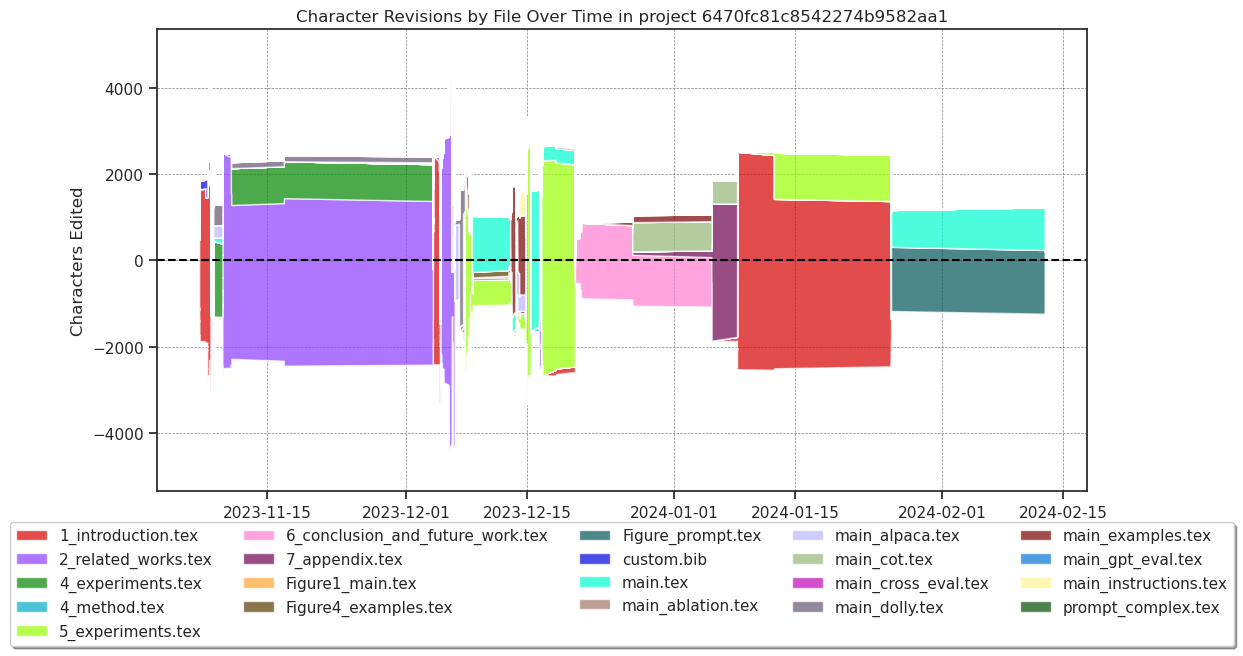

In [489]:
pivot_df = pd.pivot_table(df, values="edits", index="timestamp", columns="file", aggfunc="sum", fill_value=0)

relevant_files = [col for col in pivot_df.columns if '.tex' in col or '.bib' in col]

pivot_df = pivot_df[relevant_files]
window_size = 50  # Adjust the window size as needed
pivot_df = pivot_df.rolling(window=window_size).mean()

print(pivot_df.index)
pivot_df.index = pd.to_datetime(pivot_df.index, unit="ms")

fig, ax = plt.subplots(figsize=(12, 6)) 

#colors = sns.color_palette('hls', len(pivot_df.columns))
colors = sns.color_palette(cc.glasbey, n_colors=len(pivot_df.columns))

ax.set_prop_cycle('color', colors)

ax.stackplot(pivot_df.index, pivot_df.values.T, labels=pivot_df.columns, alpha=0.7, baseline="sym")

# Add labels and title
ax.set_xlabel('Timestamp')
ax.set_ylabel('Characters Edited')
ax.set_title(f'Character Revisions by File Over Time in project {project_id}')
ax.set_ylim((-5350, 5350))
ax.axhline(0, color="black", ls="--");
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.grid(which="major", color="grey", linestyle="--", linewidth=0.5)
#ax.set_yscale("symlog")


ax.legend(pivot_df.columns,loc='upper center', bbox_to_anchor=(0.5, -0.05),
          fancybox=True, shadow=True, ncol=5)

fig.savefig(f"figures/{project_id}_character_revisions_stackplot.png")


Index([1699312978052, 1699312980059, 1699312990246, 1699312991344,
       1699312991693, 1699312991992, 1699312992342, 1699312992672,
       1699312999307, 1699313043191,
       ...
       1706233490600, 1706233752767, 1706233922808, 1706234008877,
       1706234064660, 1706234068363, 1706234070604, 1706234437129,
       1707767081128, 1707767081286],
      dtype='int64', name='timestamp', length=7361)


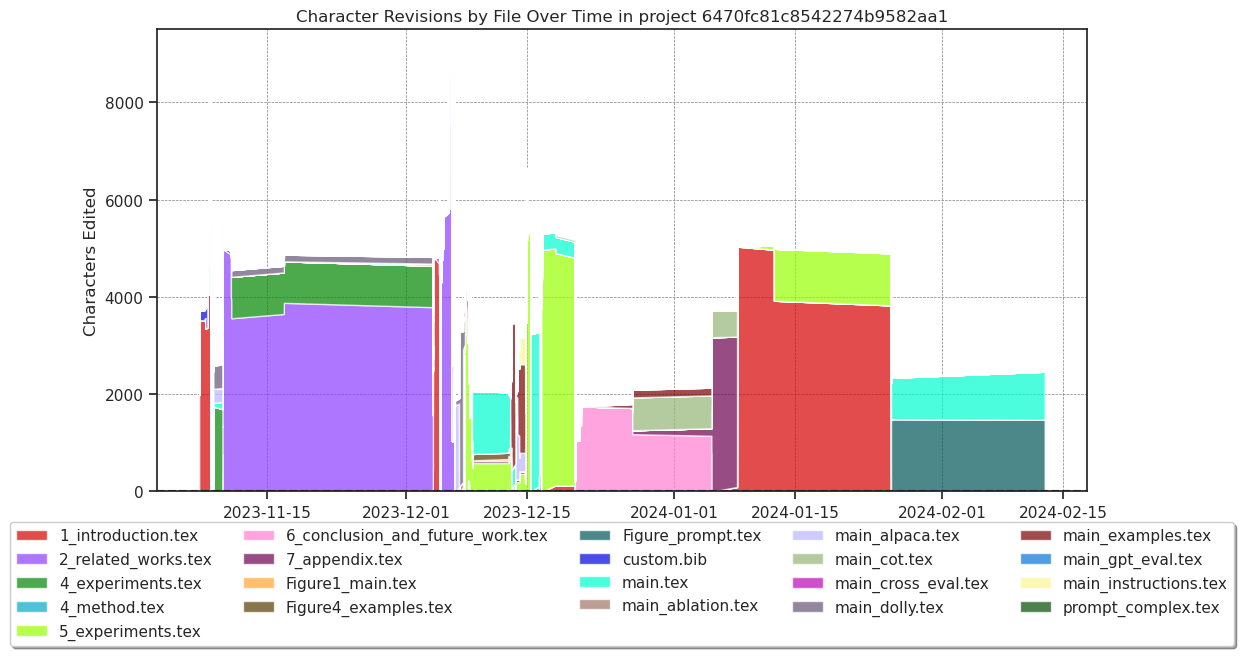

In [490]:
pivot_df = pd.pivot_table(df, values="edits", index="timestamp", columns="file", aggfunc="sum", fill_value=0)

relevant_files = [col for col in pivot_df.columns if '.tex' in col or '.bib' in col]

pivot_df = pivot_df[relevant_files]
window_size = 50  # Adjust the window size as needed
pivot_df = pivot_df.rolling(window=window_size).mean()

print(pivot_df.index)
pivot_df.index = pd.to_datetime(pivot_df.index, unit="ms")

fig, ax = plt.subplots(figsize=(12, 6)) 

#colors = sns.color_palette('hls', len(pivot_df.columns))
colors = sns.color_palette(cc.glasbey, n_colors=len(pivot_df.columns))

ax.set_prop_cycle('color', colors)

ax.stackplot(pivot_df.index, pivot_df.values.T, labels=pivot_df.columns, alpha=0.7, baseline="zero")

# Add labels and title
ax.set_xlabel('Timestamp')
ax.set_ylabel('Characters Edited')
ax.set_title(f'Character Revisions by File Over Time in project {project_id}')
#ax.set_ylim((0, 6000))
ax.axhline(0, color="black", ls="--");
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.grid(which="major", color="grey", linestyle="--", linewidth=0.5)
#ax.set_yscale("symlog")


ax.legend(pivot_df.columns,loc='upper center', bbox_to_anchor=(0.5, -0.05),
          fancybox=True, shadow=True, ncol=5)

fig.savefig(f"figures/{project_id}_character_revisions_stackplot_updated.png", bbox_inches='tight')


Index([1699312978052, 1699312980059, 1699312990246, 1699312991344,
       1699312991693, 1699312991992, 1699312992342, 1699312992672,
       1699312999307, 1699313043191,
       ...
       1706233490600, 1706233752767, 1706233922808, 1706234008877,
       1706234064660, 1706234068363, 1706234070604, 1706234437129,
       1707767081128, 1707767081286],
      dtype='int64', name='timestamp', length=7361)


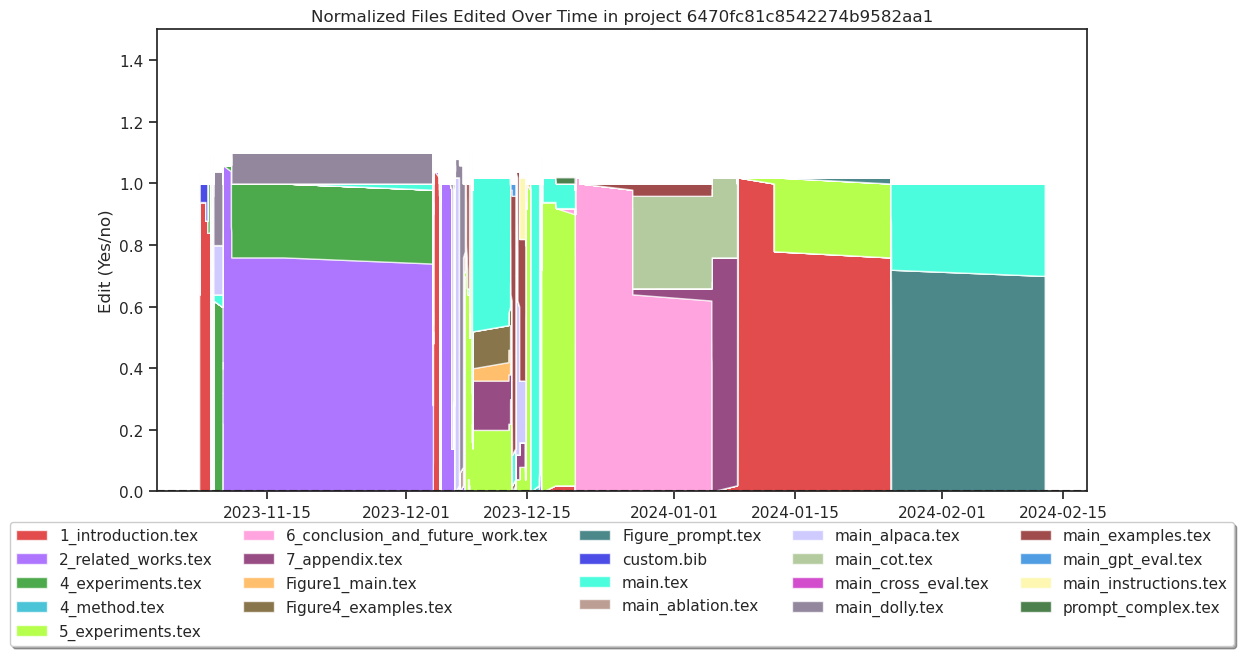

In [491]:
pivot_df = pd.pivot_table(df, values="edits", index="timestamp", columns="file", aggfunc="size", fill_value=0)

relevant_files = [col for col in pivot_df.columns if '.tex' in col or '.bib' in col]

pivot_df = pivot_df[relevant_files]
window_size = 50  # Adjust the window size as needed
pivot_df = pivot_df.rolling(window=window_size).mean()

print(pivot_df.index)
pivot_df.index = pd.to_datetime(pivot_df.index, unit="ms")

fig, ax = plt.subplots(figsize=(12, 6)) 

#colors = sns.color_palette('hls', len(pivot_df.columns))
colors = sns.color_palette(cc.glasbey, n_colors=len(pivot_df.columns))

ax.set_prop_cycle('color', colors)

ax.stackplot(pivot_df.index, pivot_df.values.T, labels=pivot_df.columns, alpha=0.7, baseline="zero")

# Add labels and title
ax.set_title(f'Normalized Files Edited Over Time in project {project_id}')
ax.set_xlabel('Timestamp')
ax.set_ylabel('Edit (Yes/no)')
#ax.set_title('Edit (Yes/no)')
ax.set_ylim((0, 1.5))
ax.axhline(0, color="black", ls="--");
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))


ax.legend(pivot_df.columns,loc='upper center', bbox_to_anchor=(0.5, -0.05),
          fancybox=True, shadow=True, ncol=5)

fig.savefig(f"figures/{project_id}_file_edits_stackplot.png")

In [492]:
import diff_match_patch as dmp_module

dmp = dmp_module.diff_match_patch()

state
Typing      6542
Paste        638
Copy         215
UndoRedo      21
Cut            5
Scroll         2
Switch         2
Name: count, dtype: int64


/home/ross/miniconda3/envs/ml39/lib/python3.9/site-packages/seaborn/categorical.py:486: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`



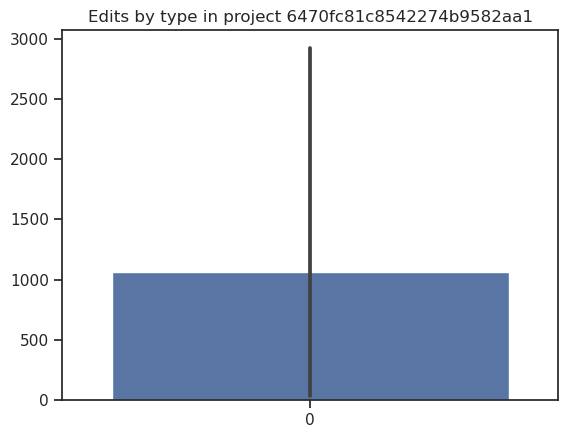

In [493]:
data = df["state"].value_counts()
print(data)
sns.barplot(data).set_title(f'Edits by type in project {project_id}')

fig.savefig(f"figures/{project_id}_edits_by_type.png")



In [494]:
idx = 12

print(df.iloc[idx]["state"])
print(df.iloc[idx]["file"])
print(df.iloc[idx]["text"])
print(df.iloc[idx]["revision"])
print("\nLen:", len(df.iloc[idx]["revision"]))
df.head()

Typing
1_introduction.tex
\section{Introduction}

Large Language Models (LLMs) today are becoming generalizable and yet show remarkable performance specifically on a variety of specific tasks. However, to be the best at certain tasks they need to be finetuned on those tasks.  LLMs have billions of parameters; LLAMA 2 has 7B, 13B \& 70B parameters for example. Hence, we need effective ways to finetune these models which require less resources and time. One way to do this is using a recent method called Instruction Tuning \citep{wei2022finetuned}. Instruction Tuning can harness the power of LLMs without extensive retraining. However, the amount of data we use further increases the computation. Some Recent methods such as LIMA \citep{zhou2023lima} have shown that less amount of more informative data can perform the same as a huge quantity of data, containing a lot of redundant less informative data points. However, LIMA is based on extensive human annotation and dataset preparation. Hence

,_id,timestamp,text,revision,state,line,username,project,file,editingLines,...,target,suggestion,explanation,accept,start,clipboard,assistError,line_counts,edits,cum_edits
0,65497552f0485be5bf50b2a4,1699312978052,\section{Introduction}\n\nLarge Language Model...,"[[0, \section{Introduction}\n\nLarge Language ...",Typing,4,Ritik Sachin,6470fc81c8542274b9582aa1,1_introduction.tex,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16,1934,1934
1,65497554f0485be5bf50b2a5,1699312980059,\section{Introduction}\n\nLarge Language Model...,"[[0, \section{Introduction}\n\nLarge Language ...",Typing,5,Ritik Sachin,6470fc81c8542274b9582aa1,1_introduction.tex,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17,1935,3869
2,6549755ef0485be5bf50b2a6,1699312990246,\section{Introduction}\n\nLarge Language Model...,"[[0, \section{Introduction}\n\nLarge Language ...",Typing,4,Ritik Sachin,6470fc81c8542274b9582aa1,1_introduction.tex,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16,1935,5804
3,6549755ff0485be5bf50b2a7,1699312991344,\section{Introduction}\n\nLarge Language Model...,"[[0, \section{Introduction}\n\nLarge Language ...",Typing,4,Ritik Sachin,6470fc81c8542274b9582aa1,1_introduction.tex,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16,1934,7738
4,65497560f0485be5bf50b2a8,1699312991693,\section{Introduction}\n\nLarge Language Model...,"[[0, \section{Introduction}\n\nLarge Language ...",Typing,4,Ritik Sachin,6470fc81c8542274b9582aa1,1_introduction.tex,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16,1934,9672


In [495]:
import re

def get_section_edited(text, line, editingLines):
    edit_line = int(line)

    matches = list(re.finditer("\\\\section", text))

    if not matches:
        return None

    end = matches[-1].start()
    # -1 so a failed 'rfind' maps to the first line.
    newline_table = {-1: 0}
    for i, m in enumerate(re.finditer('\\n', text), 1):
        # Don't find newlines past our last match.
        offset = m.start()
        if offset > end:
            break
        newline_table[offset] = i

    matches_idx = []
    
    for m in matches:
        newline_offset = text.rfind('\n', 0, m.start())
        newline_end = text.find('\n', m.end())  # '-1' gracefully uses the end.
        line = text[newline_offset + 1:newline_end]
        line_number = newline_table[newline_offset]
        #print (line_number, line)

        matches_idx.append((line_number, line))

    if (len(matches_idx) == 0):
        #print("no matches", matches_idx)
        return None
    elif (edit_line < matches_idx[0][0]):
        return "no section"
        #raise Exception("too early")
    else:
        #print("edit_line", edit_line, "output:", next(((line_number, line) for (line_number, line) in matches_idx if line_number < edit_line), 0))
        string = next((line for (line_number, line) in matches_idx if line_number < edit_line), 0)
        if (isinstance(string, str)):
            return string[string.find("{")+1:string.find("}")]
        else:
            return None
        

    

/home/ross/miniconda3/envs/ml39/lib/python3.9/site-packages/seaborn/categorical.py:486: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`



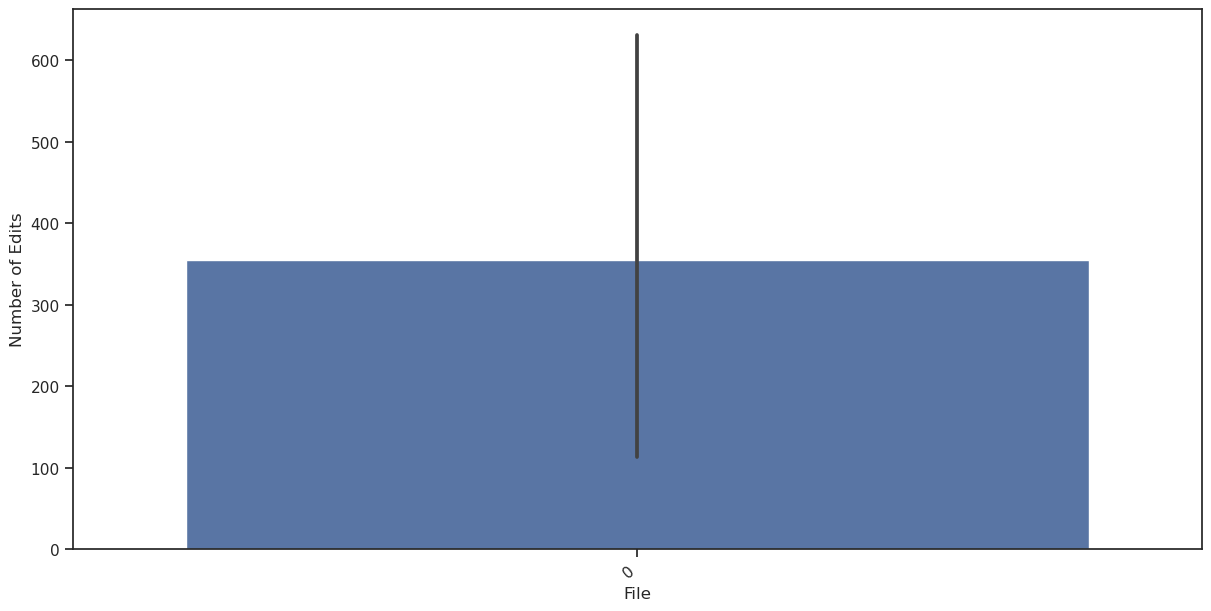

In [496]:
fig, (ax1) = plt.subplots(1, 1, constrained_layout = True,  figsize=(12,6)) 

ax1 = sns.barplot(df["file"].value_counts(), ax=ax1)
ax1.set(xlabel='File', ylabel='Number of Edits')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=40, ha="right")

fig.savefig(f"figures/{project_id}_edits_by_file.png")



In [497]:
# can manually check this to see if it is the one that you want
main_filename = df["file"].value_counts().idxmax()

print(main_filename)

df_main = df.loc[df["file"] == main_filename].reset_index()

idx = 2

state = df_main.iloc[idx]["state"]
fname = df_main.iloc[idx]["file"]
text = df_main.iloc[idx]["text"]
changes = df_main.iloc[idx]["changes"]
revision = df_main.iloc[idx]["revision"]
editingLines = df_main.iloc[idx]["editingLines"]
line = df_main.iloc[idx]["line"]



print("length", len(text))
print("total lines", text.count("\n") + 1)
print("also total lines", len(editingLines))
print("absolute line", line)

print("\n\n\n")
get_section_edited(text, line, editingLines)

1_introduction.tex
length 1934
total lines 16
also total lines 16
absolute line 4






'Introduction'

def recreate_text(revision_arr):

In [498]:
def recreate_text(revision_arr):
    text = ""
    for diff in revision_arr:
        op, data = diff[:2]
        
        if op == 0 or op == 1:
            text += data
        elif op == 2:
            raise Exception("illegal operations in diff")

    return text
        

In [499]:
df_main["full_text"] = df_main.apply(lambda x: recreate_text(x["revision"]), axis=1)

df_main["section"] = df_main.apply(lambda x: get_section_edited(x["full_text"], x["line"], x["editingLines"]), axis=1)

fig, ax = plt.subplots(figsize=(12, 6)) 

sns.barplot(df_main["section"].value_counts(), ax=ax)
ax.set_title(f'Edits by section in {main_filename} in project {project_id}')
ax.set(xlabel='Section', ylabel='Edits')
ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha="right")

df_main.head()

fig.savefig(f"figures/{project_id}_edits_by_section_in_file.png")


Exception: illegal operations in diff

In [ ]:
pivot_df = pd.pivot_table(df_main, index="timestamp", columns="section", aggfunc="size", fill_value=0)
print(pivot_df.head())

window_size = 3  # Adjust the window size as needed
pivot_df = pivot_df.rolling(window=window_size).mean()

print(pivot_df.index)
pivot_df.index = pd.to_datetime(pivot_df.index, unit="ms")

fig, ax = plt.subplots(figsize=(12, 6)) 

#colors = sns.color_palette('hls', len(pivot_df.columns))
colors = sns.color_palette(cc.glasbey, n_colors=len(pivot_df.columns))

ax.set_prop_cycle('color', colors)

ax.stackplot(pivot_df.index, pivot_df.values.T, labels=pivot_df.columns, alpha=0.7, baseline="zero")

# Add labels and title
ax.set_xlabel('Timestamp')
ax.set_ylabel('Edit Type')
#ax.set_yticklabels([])
ax.set_title(f'Edits by section over time in {main_filename} in project {project_id}')
ax.set_ylim((0, 1.5))
ax.axhline(0, color="black", ls="--");
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))


ax.legend(pivot_df.columns,loc='upper center', bbox_to_anchor=(0.5, -0.05),
          fancybox=True, shadow=True, ncol=5)

fig.savefig(f"figures/{project_id}_edits_by_section_over_time.png")


In [ ]:
#cb_df = df.loc[df["cb"].notnull()]
#cb_df = df.loc[df["message"].isin(["paste", "Paste"])]
df_main["cb_counts"] =  df_main["changes"].apply(lambda x: 0 if type(x) is not str else len(x))
df_main.head()



In [ ]:
fig, ax = plt.subplots(figsize=(12, 6)) 

#colors = sns.color_palette('hls', len(pivot_df.columns))
colors = sns.color_palette(cc.glasbey, n_colors=len(pivot_df.columns))

ax.set_prop_cycle('color', colors)

print(df_main["cb_counts"])


ax.stackplot(df_main.index, df_main["cb_counts"], alpha=0.7, baseline="zero")

# Add labels and title
ax.set_xlabel('Timestamp')
ax.set_ylabel('Edit Type')
#ax.set_yticklabels([])
ax.set_title('Edits by section in {file_name} in {project_id}')
ax.set_ylim((0, 1.5))
ax.axhline(0, color="black", ls="--");
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.grid(which="major", color="grey", linestyle="--", linewidth=0.5)



ax.legend(pivot_df.columns,loc='upper center', bbox_to_anchor=(0.5, -0.05),
          fancybox=True, shadow=True, ncol=5)

fig.savefig(f"figures/{project_id}_edits_by_section_in_file.png")


In [ ]:
df_main.head()

In [ ]:
df_main["additions"] = df_main.apply(lambda x: count_op(1, x["revision"]), axis=1)
df_main["deletions"] = df_main.apply(lambda x: count_op(-1, x["revision"]), axis=1)
df_main.head()

In [ ]:
#pivot_df = pd.pivot_table(df1, index="timestamp", values="additions", aggfunc="size", fill_value=0)


df_main.index = pd.to_datetime(df_main["timestamp"], unit="ms")

#window_size = 1  # Adjust the window size as needed
#df1[["additions", "deletions"]] = df1[["additions", "deletions"]].rolling(window=window_size).mean()

fig, ax = plt.subplots(figsize=(12, 6)) 

#colors = sns.color_palette('hls', len(pivot_df.columns))
#colors = sns.color_palette(cc.glasbey, n_colors=len(pivot_df.columns))

#ax.set_prop_cycle('color', colors)

ax.stackplot(df_main.index, df_main["additions"], alpha=0.7, baseline="zero")
ax.stackplot(df_main.index, df_main["deletions"], alpha=0.7, baseline="zero")


# Add labels and title
ax.set_xlabel('Timestamp')
ax.set_ylabel('Number of characters')
ax.set_title(f'Character additions and deletions over time for {project_id}')
ax.set_yscale("symlog")
ax.set_ylim((-4500, 4500))

ax.axhline(0, color="black", ls="--");
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.grid(which="major", color="grey", linestyle="--", linewidth=0.5)


ax.legend(df_main[["additions", "deletions"]],loc='upper center', bbox_to_anchor=(0.5, -0.05),fancybox=True, shadow=True, ncol=5)

fig.savefig(f"figures/{project_id}_character_additions_deletions_over_time.png")


In [ ]:
def check(df):
    if (df["file"] == df["next_file"]):
        return "null"
    else:
        return df["next_file"]

df.head()
df["next_file"] = df["file"].shift(1)
df["next_file"] = df.apply(check, axis = 1)

In [ ]:
#df["next_file"].value_counts()
import plotly as px

#labels = list(i for i in df["next_file"].unique() if i != None and i != "null")

labels = [col for col in df["next_file"].unique() if (col != None and col != "null") and ('.tex' in col or '.bib' in col)]


n_colors = int(len(labels))
colors = px.colors.sample_colorscale("turbo", [n/(n_colors -1) for n in range(n_colors)])
colors += colors


source = []
target = []
value = []
line_colors = []

for start_idx, start in enumerate(labels):
    for end_idx, end in enumerate(labels):
        if (start == end):
            # this one should already by filtered
            continue

        volume = len(df.loc[(df['file'] == start) & (df['next_file'] == end)])

        if (volume <= 0.01):
            continue
        
        source.append(start_idx)
        target.append(end_idx + len(labels))
        value.append(volume)
        line_colors.append(colors[start_idx])

labels += labels




        

In [ ]:
for i in range(len(line_colors)):
    line_colors[i] = line_colors[i][0:-1] + ", 0.5)"
    line_colors[i] = line_colors[i].replace("rgb", "rgba")
    print(line_colors[i])
    

In [ ]:
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = 'iframe'

fig = go.Figure(data=[go.Sankey(
    node = dict(
      pad = 15,
      thickness = 20,
      line = dict(color = "black", width = 1),
      label = labels,
      color = colors
    ),
    link = dict(
      source = source, # indices correspond to labels, eg A1, A2, A1, B1, ...
      target = target,
      value = value,
      color=line_colors
  ))],
    layout = dict(
        height = 800,
        width = 800
    ))

fig.update_layout(title_text="Changes in Edited files in project: " + project_id, font_size=10)
fig.write_image(f"sankey_{project_id}.png")

fig.write_image(f"figures/{project_id}_writing_flow_sankey.png")

fig.show()


